# GDELT Filtering & Data Quality

[GDELT](https://www.gdeltproject.org/) (Global Database of Events,
Language, and Tone) is a free, open project that monitors news worldwide —
roughly **400,000+ English-language articles per day** from the open web.
All data is freely available on **Google BigQuery**.

To use GDELT for firm-level finance, we filter its firehose down to
articles mentioning organizations. The full query and post-processing
logic are in `pull_gdelt_headlines.py`.

This notebook examines the **quality** of that filtering: how much data
survives each filter stage, which companies match, and where false
positives appear.

## 1. Setup & Data Loading

In [1]:
from datetime import datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import polars as pl

from pull_gdelt_headlines import (
    SAMPLE_MONTH,
    filter_to_month,
    load_gdelt_headlines,
)
from settings import config

DATA_DIR = Path(config("DATA_DIR"))
try:
    GCP_PROJECT = config("GCP_PROJECT")
except ValueError:
    GCP_PROJECT = None
_HAS_BQ = GCP_PROJECT is not None

if _HAS_BQ:
    try:
        from google.cloud import bigquery

        client = bigquery.Client(project=GCP_PROJECT)
    except Exception:
        _HAS_BQ = False

# Derive date range from the sample month
_sm_dt = datetime.strptime(SAMPLE_MONTH, "%Y-%m").date()
SAMPLE_START = _sm_dt.strftime("%Y-%m-%d")
if _sm_dt.month == 12:
    SAMPLE_END = _sm_dt.replace(year=_sm_dt.year + 1, month=1, day=1).strftime(
        "%Y-%m-%d"
    )
else:
    SAMPLE_END = _sm_dt.replace(month=_sm_dt.month + 1, day=1).strftime("%Y-%m-%d")

/opt/homebrew/Caskroom/mambaforge/base/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.14) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
gd_sp = filter_to_month(load_gdelt_headlines(), SAMPLE_MONTH).collect()

print(f"Sample month: {SAMPLE_MONTH} ({SAMPLE_START} to {SAMPLE_END})")
print(f"Source-filtered headlines (1 month): {len(gd_sp):>10,}")

Sample month: 2025-01 (2025-01-01 to 2025-02-01)
Source-filtered headlines (1 month):     12,109


---
## Key Result: RavenPack Headline Coverage

In [3]:
_cw = pl.read_parquet(DATA_DIR / "newswire_ravenpack_crosswalk.parquet")

from pull_free_newswires import load_newswire_headlines as _load_nw

_nw_total_urls = (
    _load_nw()
    .with_columns(pl.col("date").str.to_date())
    .filter(
        (pl.col("date") >= _cw["date"].min()) & (pl.col("date") <= _cw["date"].max())
    )
    .select(pl.col("source_url").n_unique())
    .collect()
    .item()
)
_nw_matched_urls = _cw["nw_source_url"].n_unique()
_nw_match_rate = _nw_matched_urls / _nw_total_urls * 100

_rp_full = (
    pl.scan_parquet(DATA_DIR / "ravenpack_djpr.parquet")
    .with_columns(pl.col("timestamp_utc").cast(pl.Date).alias("date"))
    .filter(
        (pl.col("date") >= _cw["date"].min()) & (pl.col("date") <= _cw["date"].max())
    )
    .select("rp_story_id")
)
_rp_total_stories = _rp_full.select(pl.col("rp_story_id").n_unique()).collect().item()
_rp_matched_stories = _cw["rp_story_id"].n_unique()
_rp_match_rate = _rp_matched_stories / _rp_total_stories * 100

pl.DataFrame(
    {
        "metric": [
            "RP headlines matched",
            "NW headlines matched",
            "GDELT match rate",
            "Crosswalk pairs",
            "Date range",
        ],
        "value": [
            f"{_rp_match_rate:.1f}% ({_rp_matched_stories:,} / {_rp_total_stories:,})",
            f"{_nw_match_rate:.1f}% ({_nw_matched_urls:,} / {_nw_total_urls:,})",
            "~7% (different source ecosystems)",
            f"{len(_cw):,}",
            f"{_cw['date'].min()} to {_cw['date'].max()} ({_cw['date'].n_unique():,} dates)",
        ],
    }
)

metric,value
str,str
"""RP headlines matched""","""5.0% (843,900 / 16,806,654)"""
"""NW headlines matched""","""24.9% (894,391 / 3,590,391)"""
"""GDELT match rate""","""~7% (different source ecosyste…"
"""Crosswalk pairs""","""895,043"""
"""Date range""","""2010-12-01 to 2026-02-28 (4,10…"


---
## 2. The Filtering Funnel

Each filter in our BigQuery query cuts the data dramatically. We measure
each stage with cheap `COUNT(*)` queries against the sample month.

In [4]:
if _HAS_BQ:
    funnel_queries = {
        "1. All GKG rows (in partition window)": f"""
            SELECT COUNT(*) AS n
            FROM `gdelt-bq.gdeltv2.gkg_partitioned`
            WHERE _PARTITIONTIME >= TIMESTAMP('{SAMPLE_START}')
              AND _PARTITIONTIME < TIMESTAMP('{SAMPLE_END}')
        """,
        "2. Has headline (<PAGE_TITLE>)": f"""
            SELECT COUNT(*) AS n
            FROM `gdelt-bq.gdeltv2.gkg_partitioned`
            WHERE _PARTITIONTIME >= TIMESTAMP('{SAMPLE_START}')
              AND _PARTITIONTIME < TIMESTAMP('{SAMPLE_END}')
              AND Extras LIKE '%<PAGE_TITLE>%'
        """,
        "3. English only (TranslationInfo IS NULL)": f"""
            SELECT COUNT(*) AS n
            FROM `gdelt-bq.gdeltv2.gkg_partitioned`
            WHERE _PARTITIONTIME >= TIMESTAMP('{SAMPLE_START}')
              AND _PARTITIONTIME < TIMESTAMP('{SAMPLE_END}')
              AND Extras LIKE '%<PAGE_TITLE>%'
              AND TranslationInfo IS NULL
        """,
        "4. Has V2Organizations": f"""
            SELECT COUNT(*) AS n
            FROM `gdelt-bq.gdeltv2.gkg_partitioned`
            WHERE _PARTITIONTIME >= TIMESTAMP('{SAMPLE_START}')
              AND _PARTITIONTIME < TIMESTAMP('{SAMPLE_END}')
              AND Extras LIKE '%<PAGE_TITLE>%'
              AND TranslationInfo IS NULL
              AND V2Organizations IS NOT NULL
              AND V2Organizations != ''
        """,
    }

    print(f"Filtering funnel for GDELT GKG ({SAMPLE_START} to {SAMPLE_END}):\n")
    print(f"{'Stage':<45} {'Rows':>12} {'% of prev':>10}")
    print("-" * 69)

    funnel_counts = {}
    prev_n = None
    for label, query in funnel_queries.items():
        result = client.query(query).result()
        n = list(result)[0]["n"]
        funnel_counts[label] = n
        pct = f"{n / prev_n * 100:.1f}%" if prev_n else ""
        print(f"{label:<45} {n:>12,} {pct:>10}")
        prev_n = n

    # Add the final stage from the local data
    n_sp500 = len(gd_sp)
    pct_sp500 = f"{n_sp500 / prev_n * 100:.1f}%"
    funnel_counts["5. Local data (source-filtered)"] = n_sp500
    print(f"{'5. Local data (source-filtered)':<45} {n_sp500:>12,} {pct_sp500:>10}")
else:
    print("BigQuery not configured (GCP_PROJECT not set) — skipping filtering funnel.")
    print("Set GCP_PROJECT in .env to run these queries.")

BigQuery not configured (GCP_PROJECT not set) — skipping filtering funnel.
Set GCP_PROJECT in .env to run these queries.


In [5]:
if _HAS_BQ:
    labels = list(funnel_counts.keys())
    counts = list(funnel_counts.values())

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(labels[::-1], counts[::-1], color="steelblue", edgecolor="white")

    for bar, count in zip(bars, counts[::-1]):
        ax.text(
            bar.get_width() + max(counts) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,}",
            va="center",
            fontsize=9,
        )

    ax.set_xlabel("Number of rows")
    ax.set_title(f"GDELT Filtering Funnel ({SAMPLE_START} to {SAMPLE_END})")
    ax.set_xlim(0, max(counts) * 1.15)
    fig.tight_layout()
    plt.show()

    total_reduction = counts[0] / counts[-1] if counts[-1] > 0 else float("inf")
    print(
        f"\nTotal reduction: {counts[0]:,} -> {counts[-1]:,} ({total_reduction:.0f}x smaller)"
    )

---
## 3. Full Data Lake Coverage

The sections above analyzed a single sample month. Now we load the
full data lake to see temporal coverage and company distribution
across all available months.

In [6]:
lf = load_gdelt_headlines()
df_full = lf.collect()
print(f"Total rows in data lake: {len(df_full):,}")

Total rows in data lake: 1,746,802


### Monthly headline counts

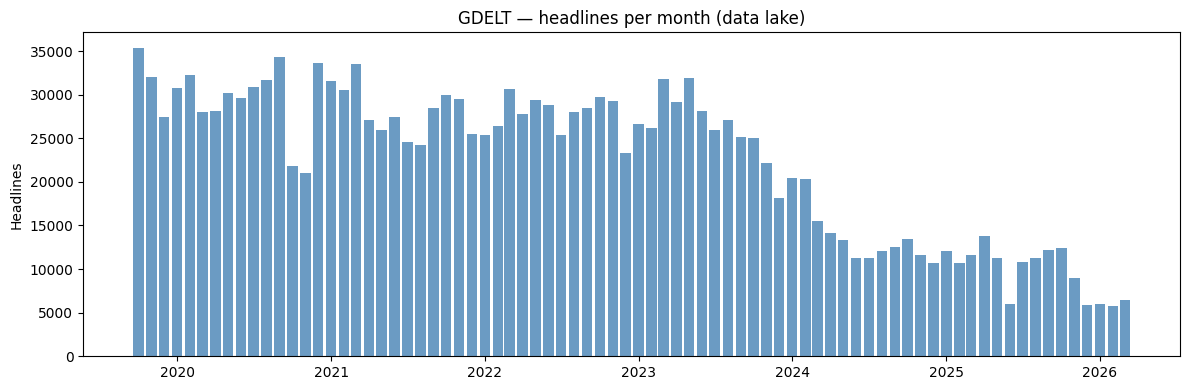

Months in data lake: 78
Date range: 2019-10-01 to 2026-03-01


In [7]:
monthly = (
    df_full.with_columns(
        pl.col("gkg_date").cast(pl.Date).dt.truncate("1mo").alias("month")
    )
    .group_by("month")
    .agg(pl.len().alias("n_headlines"))
    .sort("month")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(
    monthly["month"].to_list(),
    monthly["n_headlines"].to_list(),
    width=25,
    color="steelblue",
    alpha=0.8,
)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylabel("Headlines")
ax.set_title("GDELT — headlines per month (data lake)")
fig.tight_layout()
plt.show()

print(f"Months in data lake: {monthly.height}")
print(f"Date range: {monthly['month'].min()} to {monthly['month'].max()}")

### Distinct sources per year

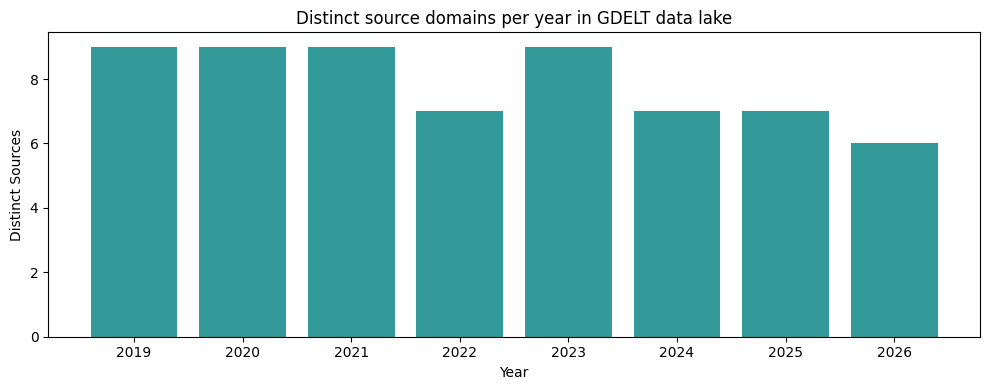

In [8]:
yearly_sources = (
    df_full.with_columns(pl.col("gkg_date").dt.year().alias("year"))
    .group_by("year")
    .agg(pl.col("source_name").n_unique().alias("n_sources"))
    .sort("year")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    yearly_sources["year"].to_list(),
    yearly_sources["n_sources"].to_list(),
    color="teal",
    alpha=0.8,
)
ax.set_xlabel("Year")
ax.set_ylabel("Distinct Sources")
ax.set_title("Distinct source domains per year in GDELT data lake")
fig.tight_layout()
plt.show()

---
## 4. Summary

**Source-domain filtering** reduces GDELT from millions of raw articles
to headlines from newswire and financial-press domains that overlap
with RavenPack's source ecosystem.

**GDELT and RavenPack draw from different source ecosystems.** GDELT
covers the open web (~98%), while RavenPack is ~95% wire services.
Only ~7% of GDELT headlines match RavenPack on a per-headline basis.
However, GDELT's enormous daily volume (hundreds of thousands of
articles) means it actually covers a **larger fraction of the
RavenPack universe** than scraped newswires alone. Newswire headlines
match at a higher per-headline rate but have smaller total volume.
Both sources are combined in the final crosswalk for maximum coverage
(see notebook 03 for the per-source breakdown).

**The full data lake** shows consistent coverage from 2019 to present.

---
## Bottom Line

In [9]:
pl.DataFrame(
    {
        "metric": [
            "RP headlines matched",
            "NW headlines matched",
            "GDELT match rate",
            "Crosswalk pairs",
            "Date range",
        ],
        "value": [
            f"{_rp_match_rate:.1f}% ({_rp_matched_stories:,} / {_rp_total_stories:,})",
            f"{_nw_match_rate:.1f}% ({_nw_matched_urls:,} / {_nw_total_urls:,})",
            "~7% (different source ecosystems)",
            f"{len(_cw):,}",
            f"{_cw['date'].min()} to {_cw['date'].max()} ({_cw['date'].n_unique():,} dates)",
        ],
    }
)

metric,value
str,str
"""RP headlines matched""","""5.0% (843,900 / 16,806,654)"""
"""NW headlines matched""","""24.9% (894,391 / 3,590,391)"""
"""GDELT match rate""","""~7% (different source ecosyste…"
"""Crosswalk pairs""","""895,043"""
"""Date range""","""2010-12-01 to 2026-02-28 (4,10…"
